In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, z, xi):

        inputs = torch.cat([z, xi], dim=1)
        return self.net(inputs)

model = PINN().to(device)

In [4]:
def physics_residual(model, z, xi): # Physics Loss

    z.requires_grad_(True)

    x = model(z, xi)

    dx = torch.autograd.grad(
        x,
        z,
        grad_outputs=torch.ones_like(x),
        create_graph=True
    )[0]

    d2x = torch.autograd.grad(
        dx,
        z,
        grad_outputs=torch.ones_like(dx),
        create_graph=True
    )[0]

    residual = d2x + 2 * xi * dx + x

    return residual

In [5]:
def initial_condition_loss(model): # Initial Condition Loss

    z0 = torch.zeros((1,1)).to(device)
    xi = torch.rand((1,1)).to(device) * 0.3 + 0.1

    z0.requires_grad_(True)

    x = model(z0, xi)

    dx = torch.autograd.grad(
        x,
        z0,
        grad_outputs=torch.ones_like(x),
        create_graph=True
    )[0]

    loss_x = (x - 0.7)**2
    loss_v = (dx - 1.2)**2

    return loss_x + loss_v

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # OPtimizer

epochs = 10000
collocation_points = 2000

In [7]:
loss_history = [] # Train Model

for epoch in range(epochs):

    z = torch.rand((collocation_points,1)).to(device) * 20
    xi = torch.rand((collocation_points,1)).to(device) * 0.3 + 0.1

    residual = physics_residual(model, z, xi)

    physics_loss = torch.mean(residual**2)

    ic_loss = initial_condition_loss(model)

    loss = physics_loss + ic_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(epoch, loss.item())

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


0 1.8769282102584839
500 0.01257233414798975
1000 0.007525445893406868
1500 0.006193623878061771
2000 0.005561513360589743
2500 0.0053583066910505295
3000 0.005960177630186081
3500 0.004367305897176266
4000 0.004096104763448238
4500 0.00340550160035491
5000 0.004681524354964495
5500 0.0030741889495402575
6000 0.0030111013911664486
6500 0.0022728198673576117
7000 0.0019962945953011513
7500 0.0021061054430902004
8000 0.0017077381489798427
8500 0.0016649046447128057
9000 0.001836693612858653
9500 0.002339342376217246


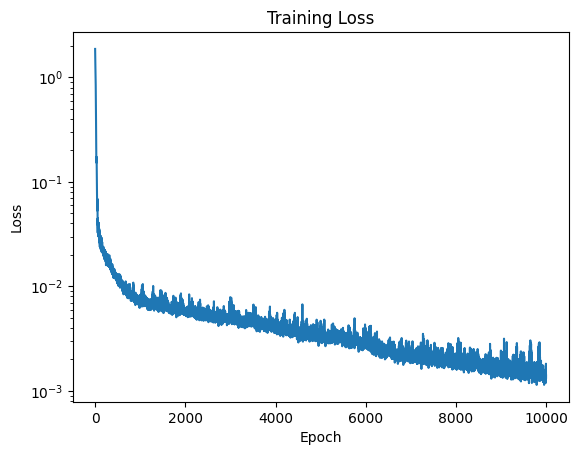

In [8]:
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

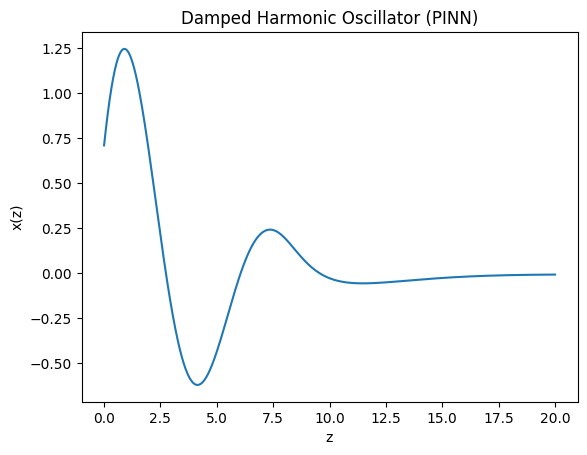

In [9]:
z_test = torch.linspace(0,20,500).unsqueeze(1).to(device) # Tests

xi_test = torch.ones_like(z_test) * 0.2

with torch.no_grad():
    x_pred = model(z_test, xi_test)

plt.plot(z_test.cpu(), x_pred.cpu())
plt.xlabel("z")
plt.ylabel("x(z)")
plt.title("Damped Harmonic Oscillator (PINN)")
plt.show()

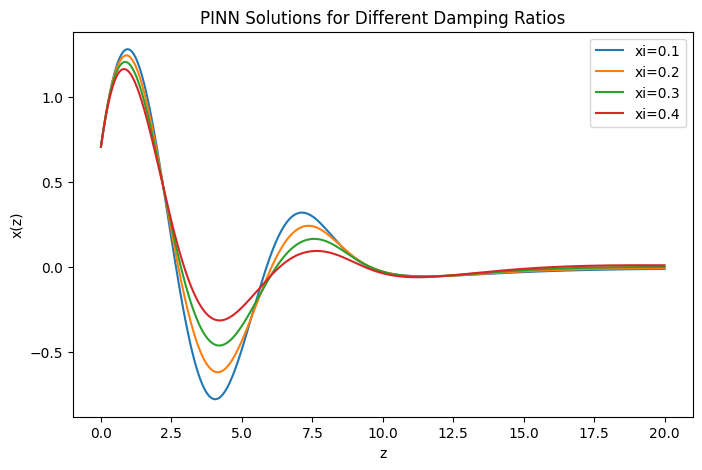

In [10]:
xis = [0.1, 0.2, 0.3, 0.4]  # Multiple Values Test

plt.figure(figsize=(8,5))

for xi_val in xis:

    xi_test = torch.ones_like(z_test) * xi_val

    with torch.no_grad():
        x_pred = model(z_test, xi_test)

    plt.plot(z_test.cpu(), x_pred.cpu(), label=f"xi={xi_val}")

plt.legend()
plt.xlabel("z")
plt.ylabel("x(z)")
plt.title("PINN Solutions for Different Damping Ratios")
plt.show()